In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tqdm
from scipy.stats import pearsonr

from polypart import Hyperplane, Polytope
from polypart.generators import (
    get_random_arrangement,
    sample_poisson_zero_cell_polytope,
)


In [2]:
def estimate_entropy(P: Polytope, cut_hyperplane: Hyperplane):
    """
    Estimate entropy of the split using number of vertices on each side.
    """
    V = P.vertices
    a, b = cut_hyperplane.normal, cut_hyperplane.offset
    num_left = np.sum(np.dot(V, a) < b)
    num_right = np.sum(np.dot(V, a) > b)
    total = num_left + num_right
    p_left = float(num_left / total)
    p_right = float(num_right / total)
    entropy = 0.0
    if p_left > 0:
        entropy -= p_left * np.log2(p_left)
    if p_right > 0:
        entropy -= p_right * np.log2(p_right)
    return entropy


def exact_entropy(P: Polytope, cut_hyperplane: Hyperplane):
    """
    Compute exact entropy of the split using volumes on each side.
    """
    P_left = P.add_halfspace(cut_hyperplane)
    vol_left = P_left.volume
    P_right = P.add_halfspace(-cut_hyperplane)
    vol_right = P_right.volume

    vol_total = vol_left + vol_right
    p_left = float(vol_left / vol_total)
    p_right = float(vol_right / vol_total)

    entropy = 0.0
    if p_left > 0:
        entropy -= p_left * float(np.log2(p_left))
    if p_right > 0:
        entropy -= p_right * float(np.log2(p_right))
    return entropy

In [3]:
# Check correlation between estimated and exact entropy
dim = 3
N = 200  # Number of samples

exact_entropies = []
estimated_entropies = []
for i in tqdm.tqdm(range(N)):
    P = sample_poisson_zero_cell_polytope(dim, 50, 1.0)
    hp = get_random_arrangement(P, 1)[0]
    est_entropy = estimate_entropy(P, hp)
    ex_entropy = exact_entropy(P, hp)
    estimated_entropies.append(est_entropy)
    exact_entropies.append(ex_entropy)


100%|██████████| 200/200 [01:13<00:00,  2.71it/s]


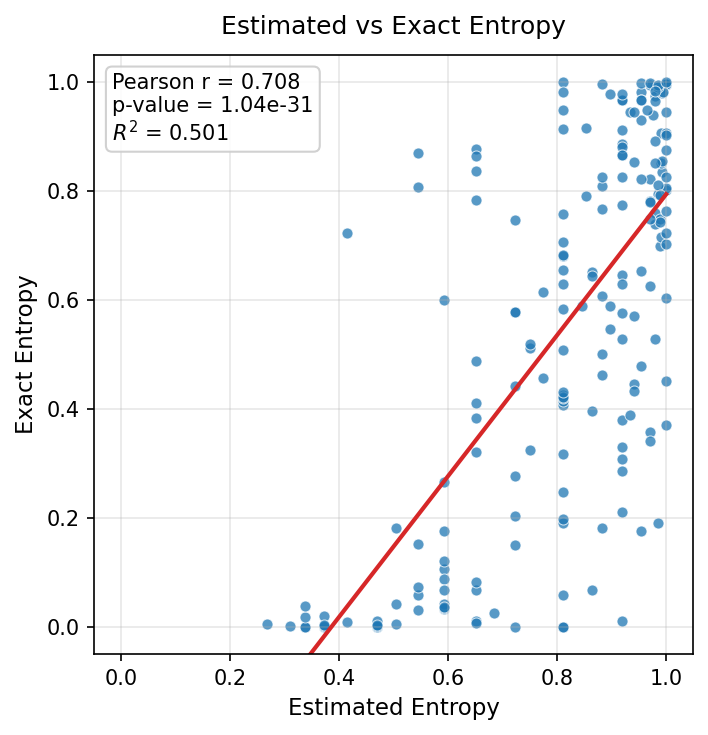

In [6]:
# Statistically determine if estimated entropy is a good proxy for exact entropy
correlation, p_value = pearsonr(estimated_entropies, exact_entropies)
# print(f"Pearson correlation coefficient: {correlation}, p-value: {p_value}")

# Professional scatter plot with linear fit and statistical annotation
x = np.asarray(estimated_entropies, dtype=float)
y = np.asarray(exact_entropies, dtype=float)

slope, intercept = np.polyfit(x, y, deg=1)
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = slope * x_fit + intercept
r_squared = correlation**2

fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
ax.scatter(
    x,
    y,
    s=28,
    alpha=0.75,
    color="#1f77b4",
    edgecolors="white",
    linewidths=0.5,
    label="Samples",
)
ax.plot(
    x_fit,
    y_fit,
    color="#d62728",
    linewidth=2.0,
    label=f"Linear fit: y = {slope:.3f}x + {intercept:.3f}",
)

ax.set_xlabel("Estimated Entropy", fontsize=11)
ax.set_ylabel("Exact Entropy", fontsize=11)
ax.set_title("Estimated vs Exact Entropy", fontsize=12, pad=10)
ax.grid(True, alpha=0.3)

stats_text = (
    f"Pearson r = {correlation:.3f}\np-value = {p_value:.2e}\n$R^2$ = {r_squared:.3f}"
)
ax.text(
    0.03,
    0.97,
    stats_text,
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.8"},
)

# ax.legend(frameon=True, fontsize=9, loc7="lower right")
fig.tight_layout()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect("equal")
plt.show()


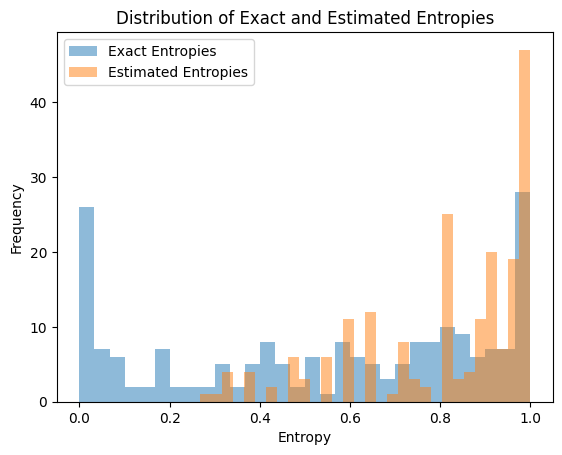

In [5]:
# Plot distribution of real entropies and estimated entropies
plt.hist(exact_entropies, bins=30, alpha=0.5, label="Exact Entropies")
plt.hist(estimated_entropies, bins=30, alpha=0.5, label="Estimated Entropies")
plt.xlabel("Entropy")
plt.ylabel("Frequency")
plt.title("Distribution of Exact and Estimated Entropies")
plt.legend()
plt.show()


The pearson test works by measuring the linear correlation between two datasets. In this case, we are comparing the estimated entropies and the exact entropies of the splits. A high positive correlation coefficient (close to 1) indicates that as one variable increases, the other variable tends to also increase, suggesting that the estimated entropy is a good proxy for the exact entropy. The p-value indicates the statistical significance of the correlation; a very low p-value (typically less than 0.05) suggests that the observed correlation is unlikely to have occurred by chance.
